In [55]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_and_process_results,
    match_datasets,
    matching_precision_recall,
    get_filenames_in_directory,
    fit_temperature,
    apply_temperature,
    fit_temperature_from_probs,
    apply_temperature_from_probs,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Ground Truth Dataset

In [2]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/pond/directory.json"), "r") as f:
    paper_info = json.load(f)

paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

paper_subset = [
    'physical-chemical_influences',
    'environmental_conditions',
    'relative_contribution',
    'monitoring_status',
    'characterizing_ponds',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes',
    'macroinvertebrate_size',
    'biodiversity_of_constructed',
    'conservation_of_pond',
]


#paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()

ground_truth_df = pd.read_csv("../data/pond/pond_data_corrected.csv", encoding_errors='ignore', index_col = 0)
ground_truth_df = ground_truth_df.loc[ground_truth_df.title.isin(registered_titles)]
ground_truth_df = ground_truth_df.reset_index(drop=True)

In [3]:
ground_truth_df

,author,title,name,location,ecosystem,date,state,attribute,value
0,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,max_depth,3.35
1,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,ph,7.78
2,chopyk et al.,agricultural freshwater pond supports diverse ...,NaN,central maryland; usa,ponds,NaN,NaN,surface_area,2600.00
3,tudor; m.; tudor; i-m; ibram; o.; teodorof; l....,analysis of biological indicators related to t...,cuibul cu lebede lake,danube delta,shallow lake,NaN,NaN,ph,8.03
4,tudor; m.; tudor; i-m; ibram; o.; teodorof; l....,analysis of biological indicators related to t...,isac lake,danube delta,shallow lake,NaN,NaN,ph,7.75
...,...,...,...,...,...,...,...,...,...
3405,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,casillas,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,206.70
3406,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,quinta,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,49.10
3407,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,ardal,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,150.90
3408,gilbert; juan diego; de vicente; inmaculada; j...,zooplankton body size versus taxonomy in medit...,hituelo,alto guadalquivir region of spain,mediterranean wetland,NaN,NaN,tp,55.50


### Data from Intermediate Pipeline steps

In [5]:
main_directory = "../data/pond"
pdf_directory = os.path.join(main_directory, "pdfs")
ocr_directory = os.path.join(main_directory, "ocr_output_cleaned_gpt_5_mini")
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)

text_files = get_filenames_in_directory(ocr_directory, ignore = [".DS_Store", ".gitkeep"])
text_files.sort()

titles = [paper_info[file.replace('.txt', '')]['title'] for file in text_files]

**1. Extracted Entities**

In [6]:
extracted_entity_data_path = "../data/experiments/2026_03_04/pond_entities.json"

with open(extracted_entity_data_path, "r") as f:
    extracted_entity_data = json.load(f)

extracted_entity_data = [e | {'title': titles[e['document_id']]} for e in extracted_entity_data]

entity_strict_fields = ["title"]
entity_fuzzy_fields = ["name", "location", "ecosystem"]

extracted_entity_df = pd.DataFrame(extracted_entity_data)
extracted_entity_df = extracted_entity_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
extracted_entity_df = extracted_entity_df.reset_index(drop=True)

ground_truth_entity_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
ground_truth_entity_df = ground_truth_entity_df.reset_index(drop=True)

In [7]:
entity_matching, entity_recall, entity_precision = matching_precision_recall(
    ground_truth_entity_df,
    extracted_entity_df,
    strict_matching = {'title': 'title'},
    fuzzy_matching = {'name':'name', 'location':'location', 'ecosystem': 'ecosystem'},
    fuzzy_threshold = 0.5
)

In [8]:
entity_recall

0.7953410981697171

In [9]:
entity_precision

0.4681684622918707

**2. Detected Attributes**

In [10]:
extracted_attribute_data_path = "../data/experiments/2026_03_04/pond_attributes.json"

with open(extracted_attribute_data_path, "r") as f:
    extracted_attribute_data = json.load(f)

extracted_attribute_dataset = []
for doc_id, attr_dict in extracted_attribute_data.items():
    for attr in attr_dict.keys():
        extracted_attribute_dataset.append({'title': titles[int(doc_id)], 'attribute': attr})

entity_strict_fields = ["title", "attribute"]

extracted_attribute_df = pd.DataFrame(extracted_attribute_dataset)
extracted_attribute_df = extracted_attribute_df.drop_duplicates(subset = entity_strict_fields)

ground_truth_attribute_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields)

In [11]:
attribute_matching, attribute_recall, attribute_precision = matching_precision_recall(
    ground_truth_attribute_df,
    extracted_attribute_df,
    strict_matching = {'title':'title', 'attribute':'attribute'},
    fuzzy_matching = {},
    fuzzy_threshold = 0.0
)

In [12]:
attribute_recall

0.9536231884057971

In [13]:
attribute_precision

0.6388349514563106

### Full, Extracted Dataset

In [4]:
# ---------------------------------
# Load experiment results
# ---------------------------------

experiment_data_path = "../data/experiments/2026_03_04/pond_judged_combined.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1.0, "fraction": 100.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)
extracted_df.reset_index(drop=True, inplace=True)

In [6]:
extracted_df.columns

Index(['title', 'author', 'year', 'paper_code', 'document_id', 'name',
       'location', 'site', 'state', 'date', 'ecosystem', 'entity_id',
       'context', 'attribute', 'value', 'units', 'page_number', 'source',
       'measurement_id', 'judgement_gpt', 'judgement_prob_gpt',
       'judgement_raw_text_gpt', 'judgement_gemini', 'judgement_prob_gemini',
       'judgement_raw_text_gemini', 'judgement_claude',
       'judgement_prob_claude', 'judgement_raw_text_claude', 'judgement_llama',
       'judgement_prob_llama', 'judgement_p_true_llama',
       'judgement_p_false_llama', 'judgement_logit_p_true_llama',
       'judgement_logit_p_false_llama', 'judgement_combined', 'table_number',
       'row_index', 'column_index', 'processed_value'],
      dtype='object')

In [9]:
extracted_df

,title,author,year,paper_code,document_id,name,location,site,state,date,...,judgement_prob_llama,judgement_p_true_llama,judgement_p_false_llama,judgement_logit_p_true_llama,judgement_logit_p_false_llama,judgement_combined,table_number,row_index,column_index,processed_value
0,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,Agricultural Pond,Mid-Atlantic United States,None,None,None,...,0.882497,0.133081,0.866919,26.502186,28.376171,True,NaN,NaN,NaN,3.35
1,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,Agricultural Pond,Mid-Atlantic United States,1 μm filter,None,October,...,0.882497,0.148143,0.851857,26.501928,28.251171,True,NaN,NaN,NaN,3.35
2,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,Agricultural Pond,Mid-Atlantic United States,0.2 μm filter,None,October,...,0.882497,0.106776,0.893224,26.376928,28.501032,False,NaN,NaN,NaN,3.35
3,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,Agricultural Pond,Mid-Atlantic United States,1 μm filter,None,November,...,0.882497,0.148160,0.851840,26.376928,28.126032,True,NaN,NaN,NaN,3.35
4,agricultural freshwater pond supports diverse ...,chopyk et al.,2018,agricultural_freshwater,0,Agricultural Pond,Mid-Atlantic United States,0.2 μm filter,None,November,...,0.882497,0.133041,0.866959,26.376701,28.251032,True,NaN,NaN,NaN,3.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7527,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,Ardal wetland,southern Spain,Ardal,None,January 2010 - December 2010,...,0.535261,0.437824,0.562177,29.250805,29.500805,True,1.0,"('Total P (μg/L)', 'Ardal')",value_mean,150.9
7528,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,Santisteban wetland,southern Spain,Santisteban,None,January 2010 - December 2010,...,0.472367,0.500024,0.499976,29.375805,29.375710,True,1.0,"('Total P (μg/L)', 'Santisteban')",value_mean,122.3
7529,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,Hituelo wetland,southern Spain,Hituelo,None,January 2010 - December 2010,...,0.472367,0.500000,0.500000,29.500710,29.500710,True,1.0,"('Total P (μg/L)', 'Hituelo')",value_mean,55.5
7530,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017,zooplankton_body,127,Quinta wetland,southern Spain,Quinta,None,January 2010 - December 2010,...,0.472367,0.500021,0.499979,29.375710,29.375626,True,1.0,"('Total P (μg/L)', 'Quinta')",value_mean,49.1


In [10]:
#extracted_df.judgement_llama = extracted_df.judgement_llama == 'true'

### Match Extractions to Ground Truth

In [11]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "title": "title", # name in the ground truth dataset : name in the extracted dataset
    "attribute": "attribute",
    "value": "processed_value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "name": "name",
    "location": "location",
    "ecosystem": "ecosystem",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, matching_recall, matching_precision = matching_precision_recall(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching,
    fuzzy_threshold = 1/3
)

print(f"Recall: {matching_recall:.4f}")
print(f"Precision: {matching_precision:.4f}")

Recall: 0.7026
Precision: 0.3181


### Debugging:

In [8]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [78]:
unmatched_gt_df.title.value_counts().head(10)

title
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa                                                               96
environmental conditions and macrophytes of karst ponds                                                                                                                            84
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            78
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             56
biodiversity of constructed wetlands for wastewater treatment                       

In [68]:
unmatched_gt_df.title.value_counts().head(10)

title
environmental conditions and macrophytes of karst ponds                                                                                                                            81
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            77
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                                         74
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             63
relationships between fish feeding guild and trophic structure in english lowland sh

In [20]:
matched_gt_df.title.value_counts()

title
vegetation-environmental variable relationships in ponds of various origins along an altitudinal gradient                        43
distinct optical chemistry of dissolved organic matter in urban pond ecosystems                                                  29
productivity and depth regulate lake contributions to atmospheric methane                                                        19
lake morphometry moderates the relationship between water color and fish biomass in small boreal lakes                           16
sediment characteristics and accumulation rates in constructed ponds                                                             10
natural variability of carbon dioxide and net epilimnetic production in the surface waters of boreal lakes of different sizes     4
fish assemblages in floodplain lakes in a neotropical river during the wet season (magdalena river; colombia)                     3
conservation of pond systems: a case study of intractability; brown mo

In [85]:
title = "biodiversity of constructed wetlands for wastewater treatment"
gt_title_df = ground_truth_df.loc[ground_truth_df.title == title]
unmatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = extracted_df.loc[extracted_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

### Judgement

In [12]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] | matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [13]:
matching_status

array([ True, False, False, ...,  True,  True,  True])

In [14]:
# Initial Precision
(extracted_df['validation'] == True).sum() / len(extracted_df)

0.5734200743494424

In [15]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

prediction_dict = {
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
    "llama": extracted_df['judgement_llama'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  FPR:       {fpr:.4f}")
    print()

Model: gpt
  TP=4123, FP=172, TN=3041, FN=196
  Accuracy:  0.9511
  Precision: 0.9600
  Recall:    0.9546
  F1:        0.9573
  FPR:       0.0535

Model: gemini
  TP=4216, FP=810, TN=2403, FN=103
  Accuracy:  0.8788
  Precision: 0.8388
  Recall:    0.9762
  F1:        0.9023
  FPR:       0.2521

Model: claude
  TP=2917, FP=4, TN=3209, FN=1402
  Accuracy:  0.8133
  Precision: 0.9986
  Recall:    0.6754
  F1:        0.8058
  FPR:       0.0012

Model: llama
  TP=978, FP=249, TN=2964, FN=3341
  Accuracy:  0.5234
  Precision: 0.7971
  Recall:    0.2264
  F1:        0.3527
  FPR:       0.0775



### Baseline Calibration

In [24]:
# ── Publication style ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})

COLORS = {
    "llama": "#1b6ca8",
    "gpt":   "#c44e52",
    "diag":  "#333333",
}

In [43]:
# ── Compute calibration values ──
def compute_calibration(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = bin_labels.mean()
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }


# ── Plot calibration ──
def plot_calibration(ax, cal, color, label, title, xlabel):
    centers = cal["centers"]
    means = cal["means"]
    ses = cal["ses"]
    counts = cal["counts"]

    # Diagonal
    ax.plot([0, 1], [0, 1], ls="--", color=COLORS["diag"], lw=1,
            label="Perfectly calibrated")

    # Shaded confidence band (±1 SE)
    ax.fill_between(
        centers, means - ses, means + ses,
        alpha=0.2, color=color, edgecolor="none",
    )
    # Main line + markers
    ax.plot(centers, means, "o-", color=color, ms=5, lw=1.5, label=label)

    # Annotate counts with a white outline for legibility
    for x, y, n in zip(centers, means, counts):
        txt = ax.annotate(
            f"$n$={n}", (x, y), textcoords="offset points",
            xytext=(0, 12), ha="center", fontsize=7.5, color="dimgray",
        )
        txt.set_path_effects([
            mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
        ])

    ax.set_xlabel(xlabel)
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")
    ax.legend(frameon=False, loc="upper left")

In [29]:
fit_temperature

<function scholarlm.utils.ml.fit_temperature(logits_true, logits_false, labels)>

In [51]:
# ── Llama baseline next token probability calibration ──
llama_p_true = extracted_df['judgement_p_true_llama'].to_numpy()
cal_llama_baseline = compute_calibration(llama_p_true, labels)

logits_true = extracted_df['judgement_logit_p_true_llama'].to_numpy()
logits_false = extracted_df['judgement_logit_p_false_llama'].to_numpy()
best_t = fit_temperature(logits_true, logits_false, labels)
llama_p_true_temp, llama_p_false_temp = apply_temperature(logits_true, logits_false, best_t)
cal_llama_baseline_temp = compute_calibration(llama_p_true_temp, labels)

### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns. 

In [16]:
def grouped_kfold_split(titles, n_splits=5, random_state=42):
    """
    Group-based k-fold CV split by paper title (no title leakage).
    
    Shuffles unique titles, then greedily assigns them to folds
    until each fold reaches ~1/k of total samples. Guarantees that
    no paper appears in more than one fold.
    
    Parameters
    ----------
    titles : array-like of str
        Paper title for each sample.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed for reproducibility.
    
    Yields
    ------
    train_idx, test_idx : np.ndarray, np.ndarray
        Integer indices for each fold.
    """
    rng = np.random.RandomState(random_state)
    titles = np.asarray(titles)
    unique_titles = np.array(list(set(titles)))
    rng.shuffle(unique_titles)
    
    n_total = len(titles)
    
    # --- Greedily assign titles to folds ---
    fold_titles = [set() for _ in range(n_splits)]
    fold_counts = [0] * n_splits
    
    # Pre-compute counts per title
    title_counts = {t: int((titles == t).sum()) for t in unique_titles}
    
    target_per_fold = n_total / n_splits
    
    for t in unique_titles:
        n_t = title_counts[t]
        # Assign to the fold that is currently most under-filled
        best_fold = min(range(n_splits), key=lambda f: fold_counts[f])
        fold_titles[best_fold].add(t)
        fold_counts[best_fold] += n_t
    
    # --- Yield train/test splits ---
    for i in range(n_splits):
        test_mask = np.isin(titles, list(fold_titles[i]))
        train_mask = ~test_mask
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        yield train_idx, test_idx

In [17]:
attn_outputs = np.load("../data/experiments/2026_03_04/pond_judged_llama_attention_outputs.npz")

# Run a logistic regression predictor for each head/layer combination, 
# and return 5-fold cross validated test accuracy.
# Uses the group-based (by-title) k-fold train/test split defined above.
def run_logistic(X, y):
    accuracies = []
    for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        accuracies.append(float(model.score(X_test, y_test)))
    return np.mean(accuracies)

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

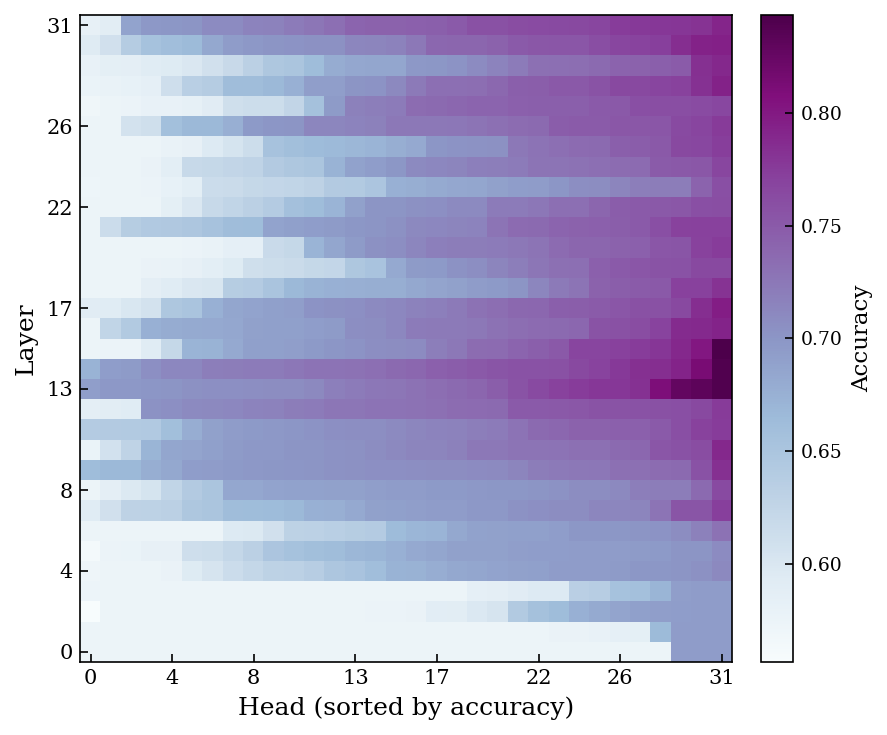

In [60]:
# ── Publication style (if not already set) ──
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})

predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)

fig, ax = plt.subplots(figsize=(6, 5))

pos = ax.imshow(predictor_accuracy_sorted, cmap="BuPu", aspect="auto", origin="lower")

ax.set_ylabel("Layer")
ax.set_xlabel("Head (sorted by accuracy)")
#ax.set_title("Attention Head Accuracies")

# Move x-axis labels/ticks to bottom (matshow puts them on top)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")

# Reduce tick clutter
n_layers, n_heads = predictor_accuracy_sorted.shape
ax.set_xticks(np.linspace(0, n_heads - 1, min(n_heads, 8)).astype(int))
ax.set_yticks(np.linspace(0, n_layers - 1, min(n_layers, 8)).astype(int))

# Colorbar
cbar = fig.colorbar(pos, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()
fig.savefig("../figures/probe.pdf", bbox_inches="tight", dpi=300)

In [34]:
from sklearn.metrics import roc_curve, auc

# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

accuracies = []
fprs = []
precisions = []
recalls = []
f1s = []
probs = []
test_labels = []
mean_fpr_grid = np.linspace(0, 1, 200)
fold_tprs = []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_bool = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_test).astype(bool)

    tp = int(((y_pred_bool == True) & (y_true == True)).sum())
    tn = int(((y_pred_bool == False) & (y_true == False)).sum())
    fp = int(((y_pred_bool == True) & (y_true == False)).sum())
    fn = int(((y_pred_bool == False) & (y_true == True)).sum())

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else float('nan')
    fold_denom = fp + tn
    fpr = (fp / fold_denom) if fold_denom > 0 else float('nan')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    fprs.append(fpr)

    # Per-fold reporting
    n_pos = int(y_true.sum())
    n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}")

    # Calibration
    y_prob = model.predict_proba(X_test)[:, 1]
    probs.append(y_prob)
    test_labels.append(y_test)

    # AUROC
    fpr_fold, tpr_fold, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_fold, tpr_fold)
    fold_aucs.append(roc_auc)

    # Interpolate TPR onto common FPR grid
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    fold_tprs.append(interp_tpr)

probs = np.concatenate(probs)
test_labels = np.concatenate(test_labels)

fold_tprs = np.array(fold_tprs)
mean_tpr = fold_tprs.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = fold_tprs.std(axis=0)
mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print()
print(f"Attn head model avg. accuracy:   {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Attn head model avg. precision:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Attn head model avg. recall:     {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Attn head model avg. F1:         {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Attn head model avg. FPR:        {np.mean(fprs):.4f} ± {np.std(fprs):.4f}")

  Fold 0: n=1433 (pos=838, neg=595) | Acc=0.8939  Prec=0.8943  Rec=0.9284  F1=0.9110  FPR=0.1546
  Fold 1: n=1439 (pos=788, neg=651) | Acc=0.8429  Prec=0.8129  Rec=0.9264  F1=0.8660  FPR=0.2581
  Fold 2: n=1610 (pos=1005, neg=605) | Acc=0.8739  Prec=0.8713  Rec=0.9363  F1=0.9026  FPR=0.2298
  Fold 3: n=1643 (pos=865, neg=778) | Acc=0.8679  Prec=0.8227  Rec=0.9549  F1=0.8839  FPR=0.2288
  Fold 4: n=1407 (pos=823, neg=584) | Acc=0.8856  Prec=0.9027  Rec=0.9016  F1=0.9021  FPR=0.1370

Attn head model avg. accuracy:   0.8729 ± 0.0175
Attn head model avg. precision:  0.8608 ± 0.0367
Attn head model avg. recall:     0.9295 ± 0.0172
Attn head model avg. F1:         0.8931 ± 0.0162
Attn head model avg. FPR:        0.2016 ± 0.0471


### MIL Probing with EM-DD

Instead of selecting a single (layer, head) position, we can treat each item as a **bag** of \(32 \times 32 = 1024\) internal representations and apply **Multiple Instance Learning**.

**Setup (Positive / Negative assumption):**
- A *positive* bag (item judged relevant) contains at least one representation that is close to an unknown concept point \(\mathbf{t}\).
- A *negative* bag (item judged irrelevant) contains *no* representations close to \(\mathbf{t}\).

We use the **EM-DD** algorithm (Zhang & Goldman, 2002) to discover \(\mathbf{t}\) from training bags and score test bags by the maximum Gaussian similarity of any instance to \(\mathbf{t}\):
$$\text{score}(B) = \max_{\mathbf{x} \in B}\; \exp\!\left(-\|\mathbf{x} - \mathbf{t}\|^2 / \sigma^2\right)$$

In [ ]:
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances


class EMDD:
    """
    EM-DD: Multiple Instance Learning via EM Diverse Density.

    Reference: Zhang & Goldman (2002), "EM-DD: An Improved Multiple-Instance
    Learning Technique".

    Finds a concept point `t` in feature space such that:
      - At least one instance in each positive bag is close to `t`
      - No instance in any negative bag is close to `t`

    Proximity is measured by a Gaussian kernel:
        p(x | t) = exp(-||x - t||^2 / sigma^2)

    Parameters
    ----------
    sigma : float or None
        Kernel bandwidth. If None, estimated from training data using the
        median pairwise distance among positive instances after preprocessing.
    n_pca_components : int or None
        If set, apply PCA to this many components before fitting (helps with
        high-dimensional attention weight vectors).
    n_restarts : int
        Number of random restarts (each seeded from a different positive
        instance).
    max_em_iters : int
        Maximum EM iterations per restart.
    max_optim_iters : int
        Maximum L-BFGS-B iterations in the M-step.
    """

    def __init__(self, sigma=None, n_pca_components=32,
                 n_restarts=10, max_em_iters=10, max_optim_iters=200):
        self.sigma            = sigma
        self.n_pca_components = n_pca_components
        self.n_restarts       = n_restarts
        self.max_em_iters     = max_em_iters
        self.max_optim_iters  = max_optim_iters
        self.t_               = None
        self.sigma_           = None
        self._scaler          = None
        self._pca             = None

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _kernel(self, X, t):
        """Gaussian kernel p(x | t) for each row of X.  Returns shape (n,)."""
        diff = X - t
        return np.exp(-np.einsum('ij,ij->i', diff, diff) / self.sigma_**2)

    def _em_objective(self, t_flat, witnesses, neg_bags):
        """
        Negated M-step surrogate objective + gradient (for scipy minimisation).

        Surrogate:
            L = sum_pos  log p(witness_i | t)
              + sum_neg  sum_j  log(1 - p(x_ij | t))
        """
        t  = t_flat
        s2 = self.sigma_**2
        obj  = 0.0
        grad = np.zeros_like(t)

        # Positive contributions: one witness per bag
        for xw in witnesses:
            diff  = xw - t
            sq    = np.dot(diff, diff) / s2
            p     = np.exp(-sq)
            obj  += np.log(p + 1e-15)
            grad += (2.0 / s2) * diff          # ∂/∂t  log p(xw | t)

        # Negative contributions: all instances
        for bag in neg_bags:
            diff  = bag - t                    # (n, d)
            sq    = np.einsum('ij,ij->i', diff, diff) / s2
            p     = np.exp(-sq)                # (n,)
            obj  += np.log(1.0 - p + 1e-15).sum()
            # ∂/∂t  log(1 - p_j) = p_j/(1-p_j) · (2/s2) · (t - x_j)
            w     = p / (1.0 - p + 1e-15)     # (n,)
            grad -= (2.0 / s2) * (w[:, None] * diff).sum(axis=0)

        return -obj, -grad

    def _log_dd(self, t, bags, labels):
        """Full log Diverse Density at concept point t."""
        score = 0.0
        for bag, y in zip(bags, labels):
            p = self._kernel(bag, t)
            if y == 1:
                # log Pr(∃ instance near t) = log(1 - ∏(1 - p_j))
                log_prod = np.log(1.0 - p + 1e-15).sum()
                score   += np.log(1.0 - np.exp(log_prod) + 1e-15)
            else:
                score += np.log(1.0 - p + 1e-15).sum()
        return score

    def _run_em(self, bags, labels, t_init):
        """Run EM from t_init; return (t, log_dd_score)."""
        pos_bags = [b for b, y in zip(bags, labels) if y == 1]
        neg_bags = [b for b, y in zip(bags, labels) if y == 0]
        t = t_init.astype(float).copy()

        for _ in range(self.max_em_iters):
            t_prev = t.copy()

            # E-step: select the most likely "witness" per positive bag
            witnesses = [b[np.argmax(self._kernel(b, t))] for b in pos_bags]

            # M-step: gradient-based optimisation of the surrogate
            res = minimize(
                self._em_objective, t, jac=True, method='L-BFGS-B',
                args=(witnesses, neg_bags),
                options={'maxiter': self.max_optim_iters, 'ftol': 1e-10},
            )
            t = res.x

            if np.linalg.norm(t - t_prev) < 1e-7:
                break

        return t, self._log_dd(t, bags, labels)

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def _transform(self, instances):
        X = self._scaler.transform(instances)
        if self._pca is not None:
            X = self._pca.transform(X)
        return X

    def fit(self, bags, labels):
        """
        Parameters
        ----------
        bags   : list of n arrays, each shape (n_instances, n_features)
        labels : int array of length n, values in {0, 1}
        """
        labels = np.asarray(labels, dtype=int)

        # Fit scaler + optional PCA on all training instances
        all_inst     = np.vstack(bags)
        self._scaler = StandardScaler().fit(all_inst)
        scaled       = self._scaler.transform(all_inst)
        if self.n_pca_components is not None:
            self._pca = PCA(n_components=self.n_pca_components,
                            random_state=42).fit(scaled)
        else:
            self._pca = None
        bags_t = [self._transform(b) for b in bags]

        # Estimate sigma via median pairwise distance among positive instances
        if self.sigma is not None:
            self.sigma_ = float(self.sigma)
        else:
            pos_inst = np.vstack([b for b, y in zip(bags_t, labels) if y == 1])
            rng_s    = np.random.RandomState(0)
            if len(pos_inst) > 500:
                pos_inst = pos_inst[rng_s.choice(len(pos_inst), 500, replace=False)]
            D        = euclidean_distances(pos_inst)
            tri      = D[np.triu_indices_from(D, k=1)]
            self.sigma_ = float(np.median(tri)) if len(tri) > 0 else 1.0

        # EM-DD with multiple random restarts
        pos_bags = [b for b, y in zip(bags_t, labels) if y == 1]
        rng      = np.random.RandomState(42)
        best_t, best_score = None, -np.inf

        for _ in range(self.n_restarts):
            bag   = pos_bags[rng.randint(len(pos_bags))]
            t0    = bag[rng.randint(len(bag))]
            t, sc = self._run_em(bags_t, labels, t0)
            if sc > best_score:
                best_score, best_t = sc, t

        self.t_ = best_t
        return self

    def decision_function(self, bags):
        """Score each bag by the max-instance Gaussian similarity to t_."""
        return np.array([
            self._kernel(self._transform(b), self.t_).max()
            for b in bags
        ])

    def predict(self, bags, threshold=0.5):
        return (self.decision_function(bags) >= threshold).astype(int)

In [ ]:
# Build bags: for each item collect all (layer, head) representations
# into a single (1024, 128) matrix — the full "bag" for that item.
n_items  = len(extracted_df)
mil_bags = []
for i in range(n_items):
    measurement_id = str(extracted_df.iloc[i, :].measurement_id)
    attn           = attn_outputs[measurement_id]          # (32, 32, 128)
    bag            = attn.reshape(-1, attn.shape[-1]).astype(np.float32)  # (1024, 128)
    mil_bags.append(bag)

mil_y = labels.astype(int)

# 5-fold grouped CV (same split as the single-head probes above)
titles              = extracted_df['title'].values
mil_accuracies      = []
mil_precisions      = []
mil_recalls         = []
mil_f1s             = []
mil_fprs            = []
mil_probs           = []
mil_test_labels_all = []
mil_fold_tprs       = []
mil_fold_aucs       = []
mean_fpr_grid_mil   = np.linspace(0, 1, 200)

for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(titles)):
    bags_train = [mil_bags[i] for i in train_idx]
    bags_test  = [mil_bags[i] for i in test_idx]
    y_train    = mil_y[train_idx]
    y_test     = mil_y[test_idx]

    model = EMDD(n_pca_components=32, n_restarts=10, max_em_iters=10)
    model.fit(bags_train, y_train)

    y_prob      = model.decision_function(bags_test)
    y_pred      = (y_prob >= 0.5).astype(int)
    y_true      = y_test.astype(bool)
    y_pred_bool = y_pred.astype(bool)

    tp = int(( y_pred_bool &  y_true).sum())
    tn = int((~y_pred_bool & ~y_true).sum())
    fp = int(( y_pred_bool & ~y_true).sum())
    fn = int((~y_pred_bool &  y_true).sum())

    acc     = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec    = tp / (tp + fp)                   if (tp + fp) > 0          else float('nan')
    rec     = tp / (tp + fn)                   if (tp + fn) > 0          else float('nan')
    f1      = 2*prec*rec / (prec + rec)        if (prec + rec) > 0       else float('nan')
    fpr_val = fp / (fp + tn)                   if (fp + tn) > 0          else float('nan')

    mil_accuracies.append(acc);  mil_precisions.append(prec)
    mil_recalls.append(rec);     mil_f1s.append(f1);  mil_fprs.append(fpr_val)

    n_pos = int(y_true.sum());  n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr_val:.4f}")

    mil_probs.append(y_prob)
    mil_test_labels_all.append(y_test)

    fpr_fold, tpr_fold, _ = roc_curve(y_test, y_prob)
    mil_fold_aucs.append(auc(fpr_fold, tpr_fold))
    interp_tpr    = np.interp(mean_fpr_grid_mil, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    mil_fold_tprs.append(interp_tpr)

mil_probs_all  = np.concatenate(mil_probs)
mil_labels_cat = np.concatenate(mil_test_labels_all)

mil_fold_tprs  = np.array(mil_fold_tprs)
mil_mean_tpr   = mil_fold_tprs.mean(axis=0);  mil_mean_tpr[-1] = 1.0
mil_std_tpr    = mil_fold_tprs.std(axis=0)
mil_mean_auc   = float(np.mean(mil_fold_aucs))
mil_std_auc    = float(np.std(mil_fold_aucs))

print()
print(f"EM-DD MIL avg. accuracy:   {np.mean(mil_accuracies):.4f} ± {np.std(mil_accuracies):.4f}")
print(f"EM-DD MIL avg. precision:  {np.mean(mil_precisions):.4f} ± {np.std(mil_precisions):.4f}")
print(f"EM-DD MIL avg. recall:     {np.mean(mil_recalls):.4f} ± {np.std(mil_recalls):.4f}")
print(f"EM-DD MIL avg. F1:         {np.mean(mil_f1s):.4f} ± {np.std(mil_f1s):.4f}")
print(f"EM-DD MIL avg. FPR:        {np.mean(mil_fprs):.4f} ± {np.std(mil_fprs):.4f}")
print(f"EM-DD MIL avg. AUROC:      {mil_mean_auc:.4f} ± {mil_std_auc:.4f}")

In [35]:
matching_recall * 0.9295

0.6531032258064516

### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

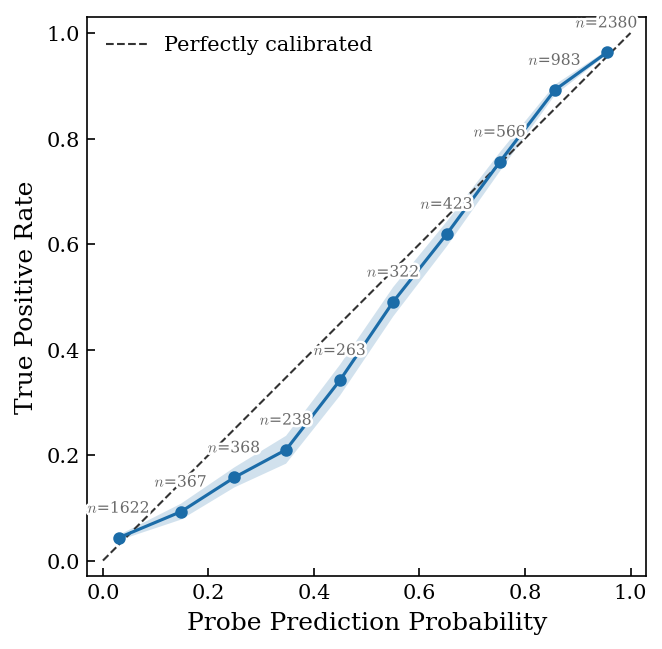

'\n# ── GPT ──\nprobs_gpt = extracted_df[\'judgement_confidence_gpt\'].to_numpy()\nprobs_gpt = np.nan_to_num(probs_gpt, nan=0.0)\ntest_labels_gpt = labels\n\ncal_gpt = compute_calibration(probs_gpt, test_labels_gpt)\n\nfig, ax = plt.subplots(figsize=(4.5, 4.5))\nplot_calibration(\n    ax, cal_gpt,\n    color=COLORS["gpt"],\n    label=None,\n    title="GPT Calibration",\n    xlabel=r"Next token $P(true)$",\n)\nplt.tight_layout()\nplt.show()\n'

In [45]:
# ── Llama ──
cal_llama = compute_calibration(probs, test_labels)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_calibration(
    ax, cal_llama,
    color=COLORS["llama"],
    label=None,
    title=None,
    xlabel="Probe Prediction Probability",
)
plt.tight_layout()
plt.show()

'''
# ── GPT ──
probs_gpt = extracted_df['judgement_confidence_gpt'].to_numpy()
probs_gpt = np.nan_to_num(probs_gpt, nan=0.0)
test_labels_gpt = labels

cal_gpt = compute_calibration(probs_gpt, test_labels_gpt)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_calibration(
    ax, cal_gpt,
    color=COLORS["gpt"],
    label=None,
    title="GPT Calibration",
    xlabel=r"Next token $P(true)$",
)
plt.tight_layout()
plt.show()
'''

In [46]:
def plot_calibration(
    ax,
    calibrations,          # list of dicts: {centers, means, ses, counts, color, label}
    title="",
    xlabel="Predicted Probability",
    ylabel="True Positive Rate",
    annotate=True,
    annotation_fontsize=7.5,
    legend_loc="upper left",
    xlim=(-0.03, 1.03),
    ylim=(-0.03, 1.03),
):
    """
    Plot one or more calibration curves on a single Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    calibrations : list of dict
        Each dict must contain:
            centers : array-like – bin midpoints
            means   : array-like – observed positive rate per bin
            ses     : array-like – standard error per bin
            counts  : array-like – sample count per bin
            color   : str        – line / fill color
            label   : str        – legend label
    title, xlabel, ylabel : str
    annotate : bool
        If True, label each point with its bin count.
    annotation_fontsize : float
    legend_loc : str
    xlim, ylim : tuple
    """
    # ── Diagonal reference ──
    ax.plot(
        [0, 1], [0, 1],
        ls="--", color=COLORS["diag"], lw=0.8,
        label="Perfectly calibrated", zorder=1,
    )

    # ── Each calibration curve ──
    for cal in calibrations:
        centers = cal["centers"]
        means   = cal["means"]
        ses     = cal["ses"]
        counts  = cal["counts"]
        color   = cal["color"]
        label   = cal["label"]

        # Shaded ±1 SE band
        ax.fill_between(
            centers, means - ses, means + ses,
            alpha=0.18, color=color, edgecolor="none", zorder=2,
        )
        # Line + markers
        ax.plot(
            centers, means, "o-",
            color=color, ms=4, lw=1.4, label=label, zorder=3,
        )
        # Bin-count annotations
        if annotate:
            for x, y, n in zip(centers, means, counts):
                txt = ax.annotate(
                    f"$n$={n}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=annotation_fontsize,
                    color="dimgray",
                )
                txt.set_path_effects([
                    mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
                ])

    # ── Axes formatting ──
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    # Lighten spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.4")
    ax.tick_params(width=0.6, color="0.4", labelsize=8)

    ax.legend(frameon=False, loc=legend_loc, fontsize=8)

In [56]:
cal_llama = compute_calibration(probs, test_labels)
best_t = fit_temperature_from_probs(probs, 1 - probs, test_labels)
probs_temp, probs_false_temp = apply_temperature_from_probs(probs, 1 - probs, best_t)
cal_llama_temp = compute_calibration(probs_temp, test_labels)

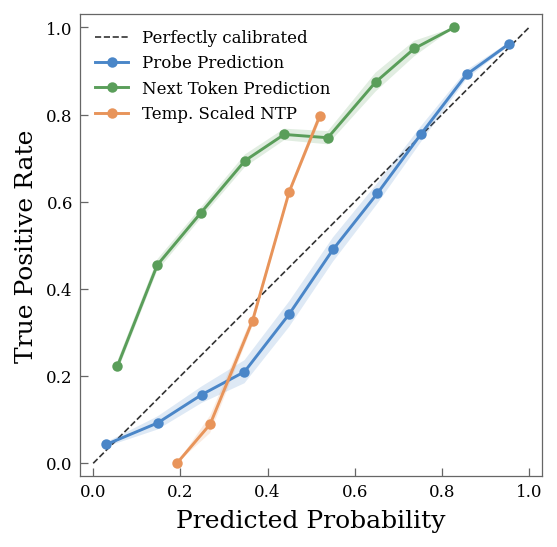

In [59]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_calibration(ax, [
    {**cal_llama, "color": "#4A86C8", "label": "Probe Prediction"},
    #{**cal_llama_temp, "color": "#ff9999", "label": "Temp. Scaled Probe Prediction"},
    {**cal_llama_baseline,   "color": "#5A9E5A", "label": "Next Token Prediction"},
    {**cal_llama_baseline_temp,   "color": "#E8945A", "label": "Temp. Scaled NTP"},
], title=None, annotate=False)
fig.savefig("../figures/calibration.pdf", bbox_inches="tight", dpi=300)

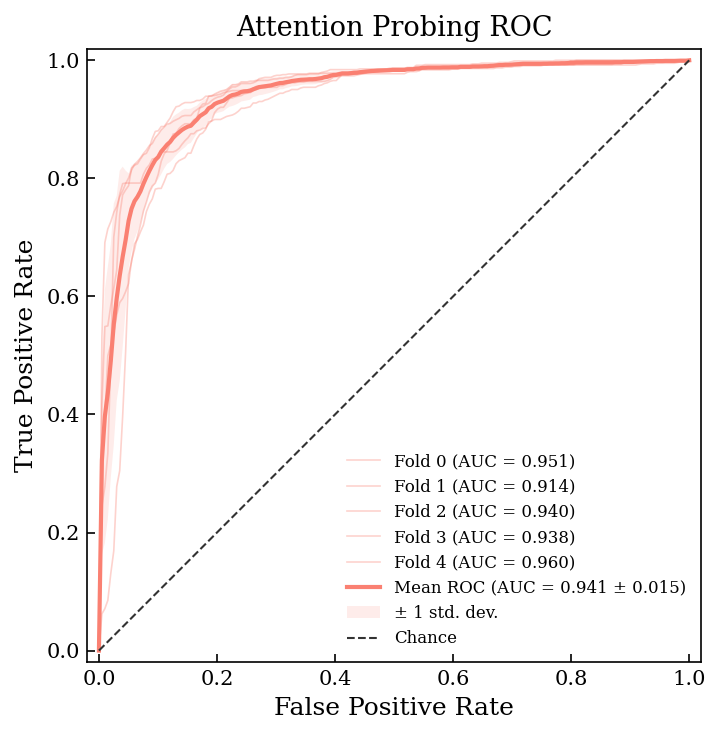

Attn head model avg. AUROC: 0.9406 ± 0.0153


In [37]:
# ── Plot ──
fig, ax = plt.subplots(figsize=(5, 5))

# Individual folds (light)
for i, (tpr_i, auc_i) in enumerate(zip(fold_tprs, fold_aucs)):
    ax.plot(mean_fpr_grid, tpr_i, lw=0.8, alpha=0.35, color="salmon",
            label=f"Fold {i} (AUC = {auc_i:.3f})")

# Mean ROC
ax.plot(mean_fpr_grid, mean_tpr, color="salmon", lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

# ±1 std band
ax.fill_between(
    mean_fpr_grid,
    np.clip(mean_tpr - std_tpr, 0, 1),
    np.clip(mean_tpr + std_tpr, 0, 1),
    color="salmon", alpha=0.15, edgecolor="none",
    label="± 1 std. dev.",
)

# Diagonal
ax.plot([0, 1], [0, 1], ls="--", color="#333333", lw=1, label="Chance")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Attention Probing ROC")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Attn head model avg. AUROC: {mean_auc:.4f} ± {std_auc:.4f}")